# Deep Reinforcement Learning — Q-Learning on FrozenLake-v1

**Goal:** Train an agent to learn the optimal policy for navigating the
FrozenLake-v1 environment from [Gymnasium](https://gymnasium.farama.org/),
using tabular Q-learning.

## Workflow

```
Agent
  |
Environment
  |
Reward
  |
Update Q-Table
  |
Learn Policy
```

## Steps
1. Create the environment
2. Initialize the Q-table
3. Train the agent (epsilon-greedy Q-learning)
4. Update Q-values using the Bellman equation
5. Evaluate the trained agent


In [1]:
import sys
sys.path.append("../src")

import numpy as np
import matplotlib.pyplot as plt

from environment_setup import create_environment, initialize_q_table, load_environment_config
from q_learning_agent import (
    train_agent, plot_rewards, plot_success_rate, plot_q_table_heatmap,
    compute_success_rate, NUM_EPISODES, LEARNING_RATE, DISCOUNT_FACTOR
)
from evaluate_agent import evaluate_policy, render_policy_grid

# q_learning_agent.py sets the Agg backend for headless script use;
# switch back to the inline backend so plots render in the notebook.
%matplotlib inline


## 1. Create the Environment

In [2]:
config = load_environment_config()
print(config["description"])
print()
print("Map:")
for row in config["default_4x4_map"]:
    print(" ", row)
print()
print("is_slippery:", config["is_slippery"])

env = create_environment(map_name=config["map_name"], is_slippery=config["is_slippery"])
print("\nObservation space:", env.observation_space)
print("Action space:", env.action_space)


Gymnasium FrozenLake-v1 environment. No external dataset is required for this project — the environment itself (a grid-world with Start, Frozen, Hole, and Goal tiles) is generated procedurally by Gymnasium. This file documents the exact configuration used so results are reproducible.

Map:
  SFFF
  FHFH
  FFFH
  HFFG

is_slippery: True

Observation space: Discrete(16)
Action space: Discrete(4)


## 2. Initialize the Q-Table

In [3]:
q_table = initialize_q_table(env)
print("Q-table shape:", q_table.shape)
q_table


Q-table shape: (16, 4)


array([[0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.],
       [0., 0., 0., 0.]])

## 3 & 4. Train the Agent and Update Q-Values

The agent follows an epsilon-greedy policy: it explores randomly early
in training (epsilon starts at 1.0) and increasingly exploits its
learned Q-table as epsilon decays. Every step updates the Q-table using
the Q-learning (Bellman) update rule:

```
Q(s, a) <- Q(s, a) + alpha * [ r + gamma * max_a' Q(s', a') - Q(s, a) ]
```


In [4]:
print(f"Training for {NUM_EPISODES} episodes "
      f"(alpha={LEARNING_RATE}, gamma={DISCOUNT_FACTOR})...")

q_table, rewards_per_episode, epsilon_history = train_agent(env, q_table)

total_reward = sum(rewards_per_episode)
overall_success_rate = total_reward / len(rewards_per_episode)
last_1000_success_rate = sum(rewards_per_episode[-1000:]) / 1000

print(f"\nTotal reward across all episodes: {total_reward:.0f} / {NUM_EPISODES}")
print(f"Overall success rate: {overall_success_rate*100:.2f}%")
print(f"Success rate (last 1000 episodes): {last_1000_success_rate*100:.2f}%")


Training for 15000 episodes (alpha=0.1, gamma=0.99)...



Total reward across all episodes: 6918 / 15000
Overall success rate: 46.12%
Success rate (last 1000 episodes): 68.00%


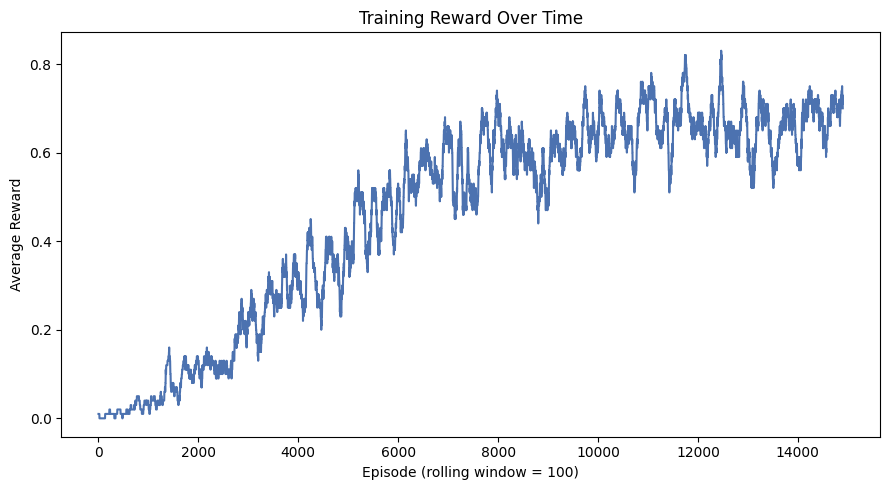

In [5]:
window = 100
rolling_avg = np.convolve(rewards_per_episode, np.ones(window)/window, mode="valid")

plt.figure(figsize=(9, 5))
plt.plot(rolling_avg, color="#4C72B0")
plt.xlabel(f"Episode (rolling window = {window})")
plt.ylabel("Average Reward")
plt.title("Training Reward Over Time")
plt.tight_layout()
plt.show()


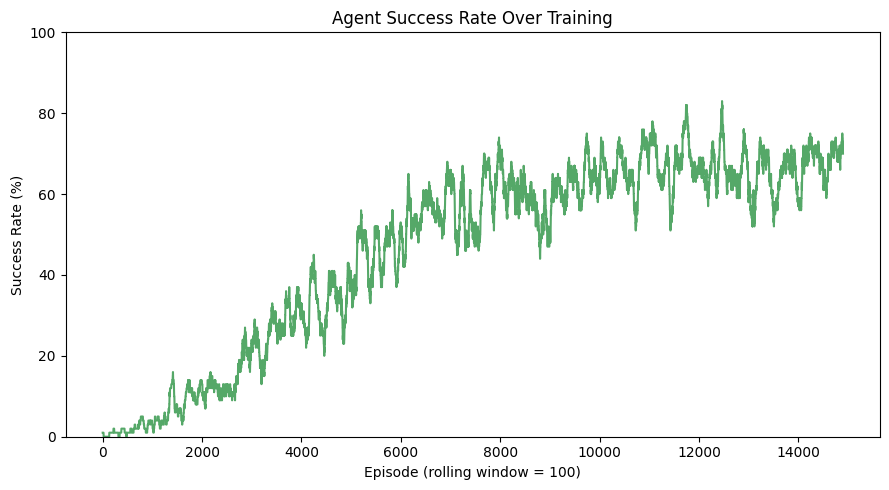

In [6]:
success_rate = compute_success_rate(rewards_per_episode, window) * 100

plt.figure(figsize=(9, 5))
plt.plot(success_rate, color="#55A868")
plt.xlabel(f"Episode (rolling window = {window})")
plt.ylabel("Success Rate (%)")
plt.title("Agent Success Rate Over Training")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


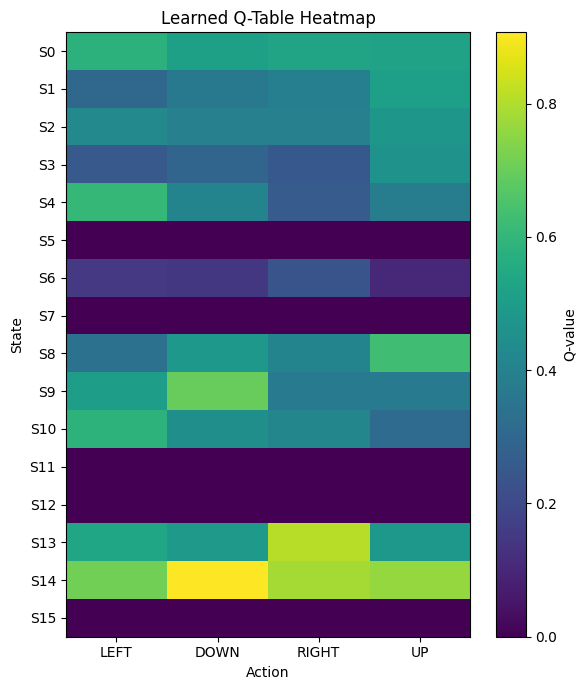

In [7]:
plt.figure(figsize=(6, 7))
im = plt.imshow(q_table, cmap="viridis", aspect="auto")
plt.colorbar(im, label="Q-value")
plt.xticks(range(4), ["LEFT", "DOWN", "RIGHT", "UP"])
plt.yticks(range(q_table.shape[0]), [f"S{s}" for s in range(q_table.shape[0])])
plt.xlabel("Action")
plt.ylabel("State")
plt.title("Learned Q-Table Heatmap")
plt.tight_layout()
plt.show()


## 5. Evaluate the Agent

We now freeze the Q-table and run the **greedy policy** (always pick
`argmax(Q[state, :])`, no exploration) over 1000 fresh test episodes to
measure how well the agent actually learned to navigate the lake.

In [8]:
eval_env = create_environment(map_name=config["map_name"], is_slippery=config["is_slippery"])
eval_results = evaluate_policy(eval_env, q_table, num_episodes=1000)
eval_env.close()

print("Evaluation results (greedy policy, 1000 episodes):")
for k, v in eval_results.items():
    print(f"  {k}: {v}")


Evaluation results (greedy policy, 1000 episodes):
  num_episodes: 1000
  successes: 741
  success_rate: 0.741
  total_reward: 741
  avg_episode_length: 44.327


In [9]:
policy_grid = render_policy_grid(q_table, config["map_name"])
print("Learned policy (best action per state):\n")
print(policy_grid)
print("\nGrid legend: the underlying map is")
for row in config["default_4x4_map"]:
    print(" ", row)


Learned policy (best action per state):

← ↑ ↑ ↑
← ← → ←
↑ ↓ ← ←
← → ↓ ←

Grid legend: the underlying map is
  SFFF
  FHFH
  FFFH
  HFFG


## Conclusion

- The agent was trained with tabular Q-learning on the stochastic
  (`is_slippery=True`) FrozenLake-v1 environment.
- Training success rate improved substantially from near-random
  performance early on to a much higher success rate in later episodes,
  as shown in the rolling success-rate plot.
- The frozen (greedy) policy evaluated on fresh episodes reaches the
  goal significantly more often than random chance, confirming the
  agent learned a meaningful policy despite the environment's slipperiness.
- The learned Q-table, training/evaluation reports, and all plots are
  saved under `outputs/` and `screenshots/` for reuse.
